#  Climate Change and Extreme Weather Events

**Research Question:** How have the frequency and economic damage of extreme weather events changed
over the past 50 years, and which world regions show the steepest acceleration?

## 1. Configuração e Obtenção de Dados

In [241]:
# Bibliotecas
import os
import glob
import pandas as pd
import seaborn as sns
import missingno as msno
import plotly.express as px
import pycountry_convert as pc
import matplotlib.pyplot as plt

In [262]:
# Funções
# Filtrar apenas os dados relativos a regiões (continentes) do planeta
def country_to_continent(country_code):
    # TLS: Timor-Leste (Asia), SXM: Sint Maarten (North America)
    # YMN: Yemen Arab Republic (Asia), DFR: Germany Federal Republic (Europe)
    # YMD: People's Democratic Republic of Yemen (Asia), YUG: Yugoslavia (Europe)
    # CSK: Czechoslovakia (Europe), SUN: Soviet Union (Europe),
    # DDR: German Democratic Republic (Europe), AZO: Azores Islands (Europe)
    # ANT: Netherlands Antilles (South America), SCG: Serbia Montenegro (Europe)
    # SPI: Canary Islands (Africa)

    ukn_asia = ['YMN', 'TLS', 'YMD']
    ukn_europe = ['AZO', 'DFR', 'YUG', 'CSK', 'SUN', 'DDR', 'SCG']
    try:
        country_code_alpha2 = pc.country_alpha3_to_country_alpha2(country_code)
        continent_code = pc.country_alpha2_to_continent_code(country_code_alpha2)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except Exception:
        if country_code == 'SPI':
            return "Africa"
        if country_code in ukn_asia:
            return "Asia"
        if country_code in ukn_europe:
            return "Europe"
        if country_code == 'ANT':
            return "South America"
        if country_code == 'SXM':
            return "North America"
        print(f"Erro ao converter {country_code}.")
        return "Other/Unknown"
    
# Exibir a quantidade e a porcentagem de valores ausentes por coluna
def show_missing_values(df):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(1)
    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct
    })

    if summary['missing_count'].sum() == 0:
        print("Não há valores ausentes no dataset.")
    else:
        print("Valores ausentes por coluna:")
        print(summary[summary['missing_count'] > 0])

# Exibir a quantidade e a porcentagem de linhas duplicadas
def show_duplicate_lines(df):
    n_duplicates = df.duplicated().sum()
    duplicates_per = n_duplicates/len(df) * 100

    print(f"Linhas duplicadas: {n_duplicates} ({duplicates_per:.2f}%)")

# Criação dos Períodos de 25 anos
def assign_period(year):
    if 1975 <= year <= 1999:
        return '1975-1999'
    elif 2000 <= year <= 2024:
        return '2000-2024'
    return 'Other'

In [243]:
path = '../data'
files = glob.glob(os.path.join(path, "*.csv"))
df_list = [pd.read_csv(f) for f in files]

extreme_weather_events   = df_list[0]
greenhouse_gas_emissions = df_list[1]
surface_temperature      = df_list[2]
temperature_anomalies    = df_list[3]

## 2. Limpeza e Filtragem (Data Cleaning)

* **Tipos de Eventos:** Droughts, Floods, Storms, Extreme Temperatures e Wildfires.
* **Recorte Temporal:** 1975 a 2024 (50 anos).
* **Agrupamento Geográfico:** África, Ásia, Europa, América do Norte, América do Sul e Oceania.

### 2.1. Análise do dataset **Extreme weather events**

Pre-2000 data is particularly subject to reporting biases.

In [244]:
rows, cols = extreme_weather_events.shape

print(f"O dataframe tem: {rows} linhas e {cols} colunas.")

show_duplicate_lines(extreme_weather_events)

print(extreme_weather_events.columns.to_list())

O dataframe tem: 11768 linhas e 8 colunas.
Linhas duplicadas: 157 (1.33%)
['Year', 'Disaster Type', 'ISO', 'Country', 'Region', 'Total Deaths', 'Total Affected', 'Adjusted Total Damage (K US$)']


In [245]:
print(extreme_weather_events.Region.unique().tolist())
display(extreme_weather_events)

['Africa', 'Asia', 'Oceania', 'Americas', 'Europe']


,Year,Disaster Type,ISO,Country,Region,Total Deaths,Total Affected,Adjusted Total Damage (K US$)
0,1975,Flood,KEN,Kenya,Africa,NaN,16000.0,NaN
1,1975,Flood,THA,Thailand,Asia,239.0,3000093.0,262298.0
2,1975,Storm,MDG,Madagascar,Africa,7.0,10050.0,NaN
3,1975,Storm,FJI,Fiji,Oceania,NaN,23000.0,5829.0
4,1975,Flood,MOZ,Mozambique,Africa,1.0,75000.0,NaN
...,...,...,...,...,...,...,...,...
11763,2000,Storm,REU,Réunion,Africa,2.0,600.0,NaN
11764,2000,Storm,IRN,Iran (Islamic Republic of),Asia,3.0,5500.0,NaN
11765,1999,Drought,UGA,Uganda,Africa,115.0,700000.0,NaN
11766,2000,Drought,SOM,Somalia,Africa,21.0,1200000.0,NaN


Como este dataset não faz a distinção entre América do Norte e do Sul, precisamos fazer uma tranformação, como base no código ISO dos países, mas que esta divisão fique correta. Em seguida eliminamos as colunas ISO e Country, para facilitar os processos seguintes.

In [246]:
extreme_weather_events['Region'] = extreme_weather_events['ISO'].apply(country_to_continent)
print(extreme_weather_events.Region.unique().tolist())
extreme_weather_events.drop(columns=['ISO', 'Country'], inplace=True)

extreme_weather_events.info()
display(extreme_weather_events.describe())
display(extreme_weather_events)

['Africa', 'Asia', 'Oceania', 'North America', 'South America', 'Europe']
<class 'pandas.DataFrame'>
RangeIndex: 11768 entries, 0 to 11767
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           11768 non-null  int64  
 1   Disaster Type                  11768 non-null  str    
 2   Region                         11768 non-null  str    
 3   Total Deaths                   8131 non-null   float64
 4   Total Affected                 8926 non-null   float64
 5   Adjusted Total Damage (K US$)  4413 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 551.8 KB


,Year,Total Deaths,Total Affected,Adjusted Total Damage (K US$)
count,11768.000000,8131.000000,8.926000e+03,4.413000e+03
mean,2005.213970,218.409913,8.923259e+05,1.244044e+06
std,12.672943,4564.128323,8.470675e+06,5.658013e+06
min,1975.000000,1.000000,1.000000e+00,6.000000e+00
25%,1997.000000,4.000000,1.013500e+03,2.246200e+04
50%,2006.000000,13.000000,1.000000e+04,1.500000e+05
75%,2016.000000,40.000000,9.979625e+04,7.204930e+05
max,2024.000000,300000.000000,3.300000e+08,2.007823e+08


,Year,Disaster Type,Region,Total Deaths,Total Affected,Adjusted Total Damage (K US$)
0,1975,Flood,Africa,NaN,16000.0,NaN
1,1975,Flood,Asia,239.0,3000093.0,262298.0
2,1975,Storm,Africa,7.0,10050.0,NaN
3,1975,Storm,Oceania,NaN,23000.0,5829.0
4,1975,Flood,Africa,1.0,75000.0,NaN
...,...,...,...,...,...,...
11763,2000,Storm,Africa,2.0,600.0,NaN
11764,2000,Storm,Asia,3.0,5500.0,NaN
11765,1999,Drought,Africa,115.0,700000.0,NaN
11766,2000,Drought,Africa,21.0,1200000.0,NaN


In [247]:
show_missing_values(extreme_weather_events)

Valores ausentes por coluna:
                               missing_count  missing_pct
Total Deaths                            3637         30.9
Total Affected                          2842         24.2
Adjusted Total Damage (K US$)           7355         62.5


<Axes: >

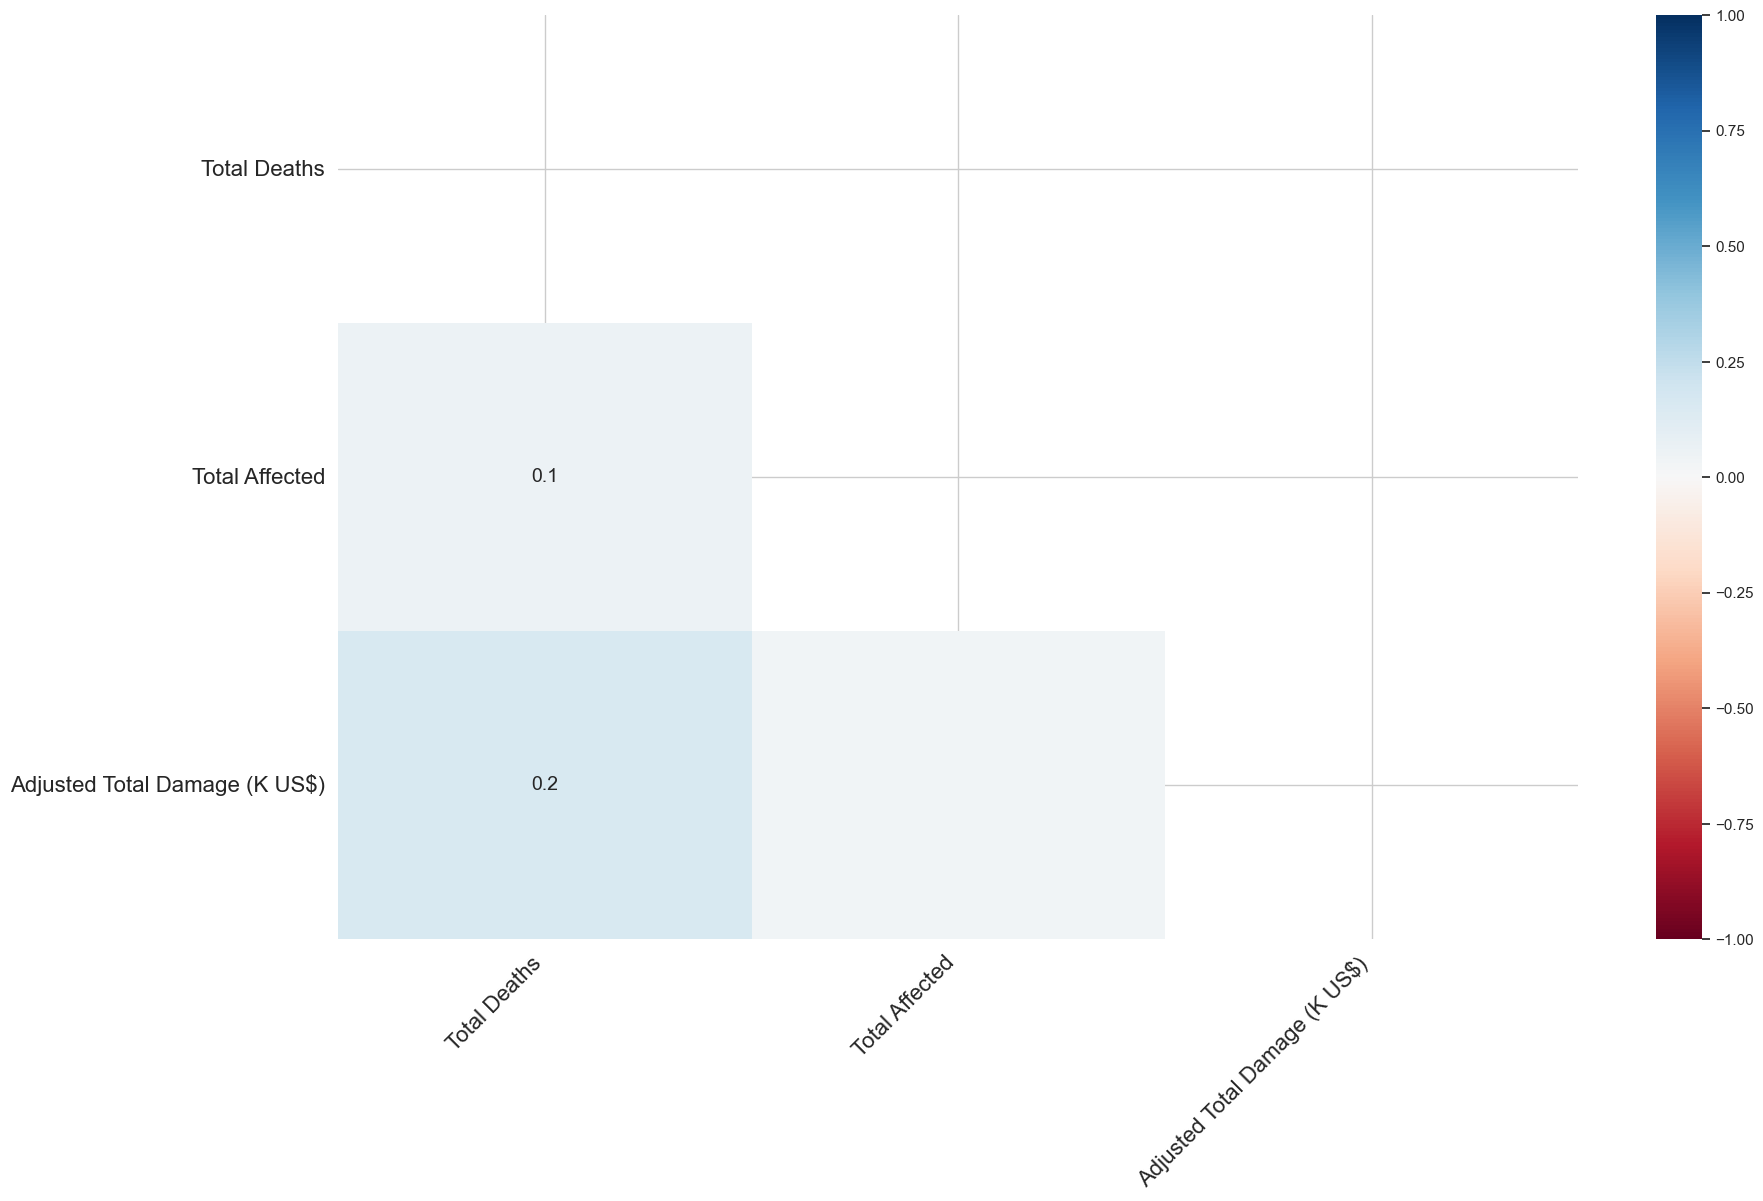

In [248]:
msno.heatmap(extreme_weather_events)

Ao analisar o heatmap acima, chegamos à conclusão que, devido aos valores próximos de 0 (zero), podemos afirmar que não há relação entre a ausência de dados das colunas.

Para melhor analisar os efeitos dos eventos climáticos extremos, resolvemos separá-los de acordo com o impacto causado (Total Deaths, Total Affected e Adjusted Total Damage).

In [249]:
ewe_deaths = extreme_weather_events.drop(columns=['Total Affected', 'Adjusted Total Damage (K US$)'])
ewe_affected = extreme_weather_events.drop(columns=['Total Deaths', 'Adjusted Total Damage (K US$)'])
ewe_damage = extreme_weather_events.drop(columns=['Total Deaths', 'Total Affected'])

#### 2.1.1 Análise do subdataset **Extreme weather events - Total Deaths**

In [250]:
show_missing_values(ewe_deaths)

Valores ausentes por coluna:
              missing_count  missing_pct
Total Deaths           3637         30.9


Este subdataset tem 3.637 valores vazios (30.9%). Contudo, como nem todo evento causa mortes, resolvemos preencher os valores vazios com 0 (zero), indicando que não houve mortes nestes desastres.

In [251]:
ewe_deaths = ewe_deaths.fillna(0)
ewe_deaths['Total Deaths'] = ewe_deaths['Total Deaths'].astype(int)
show_missing_values(ewe_deaths)
display(ewe_deaths.head())

ewe_deaths_1 = ewe_deaths.groupby(['Year', 'Region', 'Disaster Type'])['Total Deaths'].sum()
ewe_deaths_1 = ewe_deaths_1.unstack(fill_value=0).reset_index().rename_axis(None, axis=1)

ewe_deaths_1.info()
display(ewe_deaths_1.describe())
display(ewe_deaths_1)

Não há valores ausentes no dataset.


,Year,Disaster Type,Region,Total Deaths
0,1975,Flood,Africa,0
1,1975,Flood,Asia,239
2,1975,Storm,Africa,7
3,1975,Storm,Oceania,0
4,1975,Flood,Africa,1


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Year                 300 non-null    int64
 1   Region               300 non-null    str  
 2   Drought              300 non-null    int64
 3   Extreme temperature  300 non-null    int64
 4   Flood                300 non-null    int64
 5   Storm                300 non-null    int64
 6   Wildfire             300 non-null    int64
dtypes: int64(6), str(1)
memory usage: 16.5 KB


,Year,Drought,Extreme temperature,Flood,Storm,Wildfire
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1999.500000,1948.713333,1227.246667,1048.893333,1683.146667,11.636667
std,14.454981,26679.969577,7767.749344,2647.695393,11802.557012,29.120290
min,1975.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1987.000000,0.000000,0.000000,36.750000,12.000000,0.000000
50%,1999.500000,0.000000,0.000000,161.000000,67.500000,0.000000
75%,2012.000000,0.000000,150.250000,698.250000,436.000000,9.250000
max,2024.000000,450500.000000,72225.000000,30127.000000,146055.000000,240.000000


,Year,Region,Drought,Extreme temperature,Flood,Storm,Wildfire
0,1975,Africa,0,0,26,28,0
1,1975,Asia,0,14,20644,822,0
2,1975,Europe,0,0,60,0,0
3,1975,North America,0,0,0,171,0
4,1975,Oceania,0,0,0,0,0
...,...,...,...,...,...,...,...
295,2024,Asia,0,4283,2669,1663,4
296,2024,Europe,0,62557,275,60,10
297,2024,North America,0,1161,63,570,5
298,2024,Oceania,0,0,2,1,0


#### 2.1.2 Análise do subdataset **Extreme weather events - Total Affected**

In [252]:
show_missing_values(ewe_affected)

Valores ausentes por coluna:
                missing_count  missing_pct
Total Affected           2842         24.2


In [253]:
# Contagem para o período de 1975 a 1999
vazios_75_99 = ewe_affected.loc[ewe_affected['Year'] <= 1999, 'Total Affected'].isna().sum()

# Contagem para o período de 2000 a 2024
vazios_00_24 = ewe_affected.loc[ewe_affected['Year'] >= 2000, 'Total Affected'].isna().sum()

print(f"Linhas vazias (1975-1999): {vazios_75_99}")
print(f"Linhas vazias (2000-2024): {vazios_00_24}")

Linhas vazias (1975-1999): 1164
Linhas vazias (2000-2024): 1678


Apesar do aviso do EM-DAT de que os valores anteriores a 2000 estão mais sujeitos à vieses, como a quantidade de valores vazions na coluna de total de afetados é maior no período após os anos 2000, então passamos a considerar como 0 (zero), a quantidade de pessoas afetadas nos registros vazios.

In [254]:
ewe_affected = ewe_affected.fillna(0)
ewe_affected['Total Affected'] = ewe_affected['Total Affected'].astype(int)
show_missing_values(ewe_affected)
display(ewe_affected.head())

ewe_affected_1 = ewe_affected.groupby(['Year', 'Region', 'Disaster Type'])['Total Affected'].sum()
ewe_affected_1 = ewe_affected_1.unstack(fill_value=0).reset_index().rename_axis(None, axis=1)

ewe_affected_1.info()
display(ewe_affected_1.describe())
display(ewe_affected_1)

Não há valores ausentes no dataset.


,Year,Disaster Type,Region,Total Affected
0,1975,Flood,Africa,16000
1,1975,Flood,Asia,3000093
2,1975,Storm,Africa,10050
3,1975,Storm,Oceania,23000
4,1975,Flood,Africa,75000


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Year                 300 non-null    int64
 1   Region               300 non-null    str  
 2   Drought              300 non-null    int64
 3   Extreme temperature  300 non-null    int64
 4   Flood                300 non-null    int64
 5   Storm                300 non-null    int64
 6   Wildfire             300 non-null    int64
dtypes: int64(6), str(1)
memory usage: 16.5 KB


,Year,Drought,Extreme temperature,Flood,Storm,Wildfire
count,300.000000,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02
mean,1999.500000,8.789418e+06,4.702855e+05,1.299922e+07,4.228290e+06,6.245250e+04
std,14.454981,3.647078e+07,5.032289e+06,3.796798e+07,1.199001e+07,6.090032e+05
min,1975.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1987.000000,0.000000e+00,0.000000e+00,4.935650e+04,8.716000e+03,0.000000e+00
50%,1999.500000,2.375000e+04,0.000000e+00,4.173895e+05,1.186205e+05,1.900000e+01
75%,2012.000000,3.637500e+06,2.150000e+02,2.821886e+06,1.323320e+06,3.096000e+03
max,2024.000000,3.715100e+08,7.917068e+07,2.896435e+08,1.093965e+08,1.004294e+07


,Year,Region,Drought,Extreme temperature,Flood,Storm,Wildfire
0,1975,Africa,0,0,248000,846308,0
1,1975,Asia,0,0,48053448,9396,0
2,1975,Europe,0,0,1000000,0,0
3,1975,North America,0,0,0,540,0
4,1975,Oceania,0,0,0,23000,0
...,...,...,...,...,...,...,...
295,2024,Asia,266000,36377795,31898475,40507606,19900
296,2024,Europe,0,0,86657,326000,42399
297,2024,North America,100000,2567,1900177,5060799,7739
298,2024,Oceania,13924,0,6206,25134,0


#### 2.1.2 Análise do subdataset **Extreme weather events - Adjusted Total Damage (K US$)**

Procurar os dados do PIB por continente de 2025. https://en.wikipedia.org/wiki/List_of_continents_by_GDP

"GDP (Nominal), current prices". International Monetary Fund. Retrieved 15 November 2025.

In [255]:
countries_gdp = pd.DataFrame({
    "Region": ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America'],
    "Values (billions US$)": [3_058, 42_188, 29_677, 35_580, 2_137, 4_447]
})

display(countries_gdp)

,Region,Values (billions US$)
0,Africa,3058
1,Asia,42188
2,Europe,29677
3,North America,35580
4,Oceania,2137
5,South America,4447


In [256]:
show_missing_values(ewe_damage)

Valores ausentes por coluna:
                               missing_count  missing_pct
Adjusted Total Damage (K US$)           7355         62.5


Resolvemos preencher os valores vazios com zero pois nem todos os tipos de desastres geram danos econômicos registrados todos os anos em todas as regiões. Assim, não excluímos o registro que o desastre aconteceu, apesar de não ter havido ou sido registrado dano econômico.

In [257]:
# 1. Somar os valores de cada tipo de dano, agrupando por Ano e Região e preenchendo os vazios com 0
economic_damages = ewe_damage.groupby(['Year', 'Region', 'Disaster Type'])['Adjusted Total Damage (K US$)'].sum()
economic_damages = economic_damages.unstack(fill_value=0).reset_index()

# 2. Unir os dataframes pela coluna 'Region'
# Isso trará a coluna 'Values (billions US$)' para o dataframe de danos
economic_damages = pd.merge(economic_damages, countries_gdp[['Region', 'Values (billions US$)']], on='Region')

# 3. Definir as colunas que serão convertidas
disasters = ['Drought', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']

# 4. Calcular o dano como porcentagem do PIB (%)
# O fator 10.000 vem da simplificação de (Dano*10^3 / PIB*10^9) * 100
for col in disasters:
    economic_damages[col] = economic_damages[col] / (economic_damages['Values (billions US$)'] * 10_000)

economic_damages.drop(columns=['Values (billions US$)'], inplace=True)

economic_damages.info()
display(economic_damages.describe())
display(economic_damages)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 300 non-null    int64  
 1   Region               300 non-null    str    
 2   Drought              300 non-null    float64
 3   Extreme temperature  300 non-null    float64
 4   Flood                300 non-null    float64
 5   Storm                300 non-null    float64
 6   Wildfire             300 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 16.5 KB


,Year,Drought,Extreme temperature,Flood,Storm,Wildfire
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1999.500000,0.013661,0.001664,0.028864,0.039424,0.003687
std,14.454981,0.062158,0.008476,0.053189,0.093321,0.011997
min,1975.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1987.000000,0.000000,0.000000,0.001048,0.000591,0.000000
50%,1999.500000,0.000000,0.000000,0.010400,0.009811,0.000000
75%,2012.000000,0.006117,0.000000,0.036946,0.035215,0.000791
max,2024.000000,0.968640,0.078644,0.498755,0.906722,0.114833


,Year,Region,Drought,Extreme temperature,Flood,Storm,Wildfire
0,1975,Africa,0.000000,0.0,0.000000,0.038808,0.000000
1,1975,Asia,0.000000,0.0,0.010666,0.009770,0.000000
2,1975,Europe,0.000000,0.0,0.000982,0.000000,0.000000
3,1975,North America,0.000000,0.0,0.000077,0.009051,0.000000
4,1975,Oceania,0.000000,0.0,0.000000,0.000273,0.000000
...,...,...,...,...,...,...,...
295,2024,Asia,0.002323,0.0,0.036787,0.022285,0.000000
296,2024,Europe,0.000371,0.0,0.053196,0.010862,0.001954
297,2024,North America,0.015177,0.0,0.010680,0.508933,0.008179
298,2024,Oceania,0.000000,0.0,0.026673,0.000000,0.000000


### 2.2. Análise do dataset **Greenhouse gas emissions**

Greenhouse gases são os gases que contribuem para o efeito estufa (CO<sub>2</sub>, Metano e Óxido Nitroso). Os dados contém os a quantidade em toneladas per capita destes gases emitidas por cada país e em cada ano. Também é importante salientar que as emissões são referentes a produção humana destes gases, incluindo a queima de combustíveis fósseis, a atividade industrial e a produção de alimentos.

Citação em linha:

Jones et al. (2025); Population based on various sources (2024) – with major processing by Our World in Data

Citação completa:

Jones et al. (2025); Population based on various sources (2024) – with major processing by Our World in Data. “Per capita greenhouse gas emissions including land use” [dataset]. Jones et al., “National contributions to climate change 2025.1”; Various sources, “Population” [original data].

In [258]:
display(greenhouse_gas_emissions.info())

continent_codes = ['OWID_AFR', 'OWID_ASI', 'OWID_EUR', 'OWID_NAM', 'OWID_OCE', 'OWID_SAM']

gas_emissions_1 = greenhouse_gas_emissions[greenhouse_gas_emissions.Code.isin(continent_codes)].copy()

gas_emissions_1.columns = ['Region', 'Code', 'Year', 'Greenhouse gas emissions']

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
gas_emissions_1 = gas_emissions_1[gas_emissions_1['Year'].between(1975, 2024)]
gas_emissions_1 = gas_emissions_1.drop(columns=['Code'])

gas_emissions_1.info()
display(gas_emissions_1.describe())
display(gas_emissions_1)

<class 'pandas.DataFrame'>
RangeIndex: 36179 entries, 0 to 36178
Data columns (total 4 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Entity                                                  36179 non-null  str    
 1   Code                                                    36179 non-null  str    
 2   Year                                                    36179 non-null  int64  
 3   Per capita greenhouse gas emissions including land use  36179 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 1.1 MB


None

<class 'pandas.DataFrame'>
Index: 300 entries, 300 to 29968
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Region                    300 non-null    str    
 1   Year                      300 non-null    int64  
 2   Greenhouse gas emissions  300 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 9.4 KB


,Year,Greenhouse gas emissions
count,300.000000,300.000000
mean,1999.500000,12.354890
std,14.454981,7.465449
min,1975.000000,3.148923
25%,1987.000000,4.657866
50%,1999.500000,11.231280
75%,2012.000000,18.254743
max,2024.000000,32.317127


,Region,Year,Greenhouse gas emissions
300,Africa,1975,4.913611
301,Africa,1976,4.915044
302,Africa,1977,5.011398
303,Africa,1978,4.752050
304,Africa,1979,4.752768
...,...,...,...
29964,South America,2020,9.278587
29965,South America,2021,9.890444
29966,South America,2022,10.090818
29967,South America,2023,9.877732


### 2.3. Análise do dataset **Surface temperature**

In [259]:
display(surface_temperature.head())

# 1. Converter a coluna 'Day' para o formato datetime
surface_temperature['Day'] = pd.to_datetime(surface_temperature['Day'])

# 2. Criar a nova coluna 'Year' extraindo apenas o ano (formato YYYY)
surface_temperature['Year'] = surface_temperature['Day'].dt.strftime('%Y')

# Agrupando por Ano e Código, calculando média e mediana para comparação
surface_temperature_1 = surface_temperature.groupby(['Year', 'Code'])['Monthly average'].mean().reset_index()

# Renomeando as colunas para clareza
surface_temperature_1.columns = ['Year', 'Code', 'Yearly average']

# Visualizar o resultado
display(surface_temperature_1.head())

# Eliminar as linhas que correspondem a regiões globais (OWID) e adicionar uma coluna de região (continente)
surface_temperature_2 = surface_temperature_1[~surface_temperature_1.Code.str.startswith('OWID')].copy()
surface_temperature_2['Region'] = surface_temperature_2['Code'].apply(country_to_continent)

# Converter a coluna 'Year' para inteiro
surface_temperature_2['Year'] = surface_temperature_2['Year'].astype(int)

# Agrupar os dados por região e ano, somando os valores dos desastres para cada região
surface_temperature_2 = surface_temperature_2.drop(columns=['Code'])
surface_temperature_2 = surface_temperature_2.groupby(['Region', 'Year'])['Yearly average'].median().reset_index()

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
surface_temperature_2 = surface_temperature_2[surface_temperature_2['Year'].between(1975, 2024)].reset_index()
surface_temperature_2.drop(columns=['index'], inplace=True)

# Eliminar as linhas que se referem a Antarctica
surface_temperature_2 = surface_temperature_2[surface_temperature_2['Region'] != 'Antarctica']

surface_temperature_2.info()
display(surface_temperature_2.describe())
display(surface_temperature_2.head())

,Entity,Code,Day,Monthly average
0,Afghanistan,AFG,1940-01-15,-2.032494
1,Afghanistan,AFG,1940-02-15,-0.733503
2,Afghanistan,AFG,1940-03-15,1.999134
3,Afghanistan,AFG,1940-04-15,10.199754
4,Afghanistan,AFG,1940-05-15,17.942135


,Year,Code,Yearly average
0,1940,AFG,11.327695
1,1940,AGO,21.409697
2,1940,AIA,25.821704
3,1940,ALB,10.648014
4,1940,AND,3.409269


<class 'pandas.DataFrame'>
Index: 300 entries, 0 to 349
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          300 non-null    str    
 1   Year            300 non-null    int64  
 2   Yearly average  300 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 9.4 KB


,Year,Yearly average
count,300.000000,300.000000
mean,1999.500000,20.668427
std,14.454981,5.509557
min,1975.000000,7.745101
25%,1987.000000,19.716902
50%,1999.500000,22.704046
75%,2012.000000,24.739902
max,2024.000000,26.185329


,Region,Year,Yearly average
0,Africa,1975,23.463053
1,Africa,1976,23.532817
2,Africa,1977,23.945950
3,Africa,1978,23.778325
4,Africa,1979,23.850431


### 2.4. Análise do dataset **Temperature Anomalies**

In [260]:
display(temperature_anomalies.head())

# 1. Definir a lista de colunas dos meses
colunas_meses = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]

# 2. Calcular a média anual apenas para estas colunas e criar a nova coluna
# O axis=1 indica que a média é calculada horizontalmente (para cada linha)
temperature_anomalies['Yearly_anomaly_average'] = temperature_anomalies[colunas_meses].mean(axis=1)
temperature_anomalies_1 = temperature_anomalies.drop(columns=colunas_meses)

regions = [
    'Africa (NIAID)', 'Asia (NIAID)', 'Europe (NIAID)', 
    'North America (NIAID)', 'South America (NIAID)', 'Oceania (NIAID)'
]

# 2. Filtrar o DataFrame para manter apenas essas entidades
temperature_anomalies_2 = temperature_anomalies_1[temperature_anomalies_1['Entity'].isin(regions)].copy()

# 3. Limpar os nomes (remover o " (NIAID)") para facilitar a visualização
temperature_anomalies_2['Entity'] = temperature_anomalies_2['Entity'].str.replace(' (NIAID)', '', regex=False)

# Eliminar a coluna code
temperature_anomalies_3 = temperature_anomalies_2.drop(columns=['Code'])

# Renomeando as colunas para clareza
temperature_anomalies_3.columns = ['Region', 'Year', 'Yearly anomaly average']

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
temperature_anomalies_3 = temperature_anomalies_3[temperature_anomalies_3['Year'].between(1975, 2024)]

# 4. Verificar o resultado
temperature_anomalies_3.info()
display(temperature_anomalies_3.describe())
display(temperature_anomalies_3)

,Entity,Code,Year,January,February,March,April,May,June,July,August,September,October,November,December
0,Afghanistan,AFG,1940,-0.789005,-1.594132,-4.561447,-2.868090,-0.813093,0.006361,-0.850492,-1.840513,-1.719229,0.608858,-0.174298,0.167288
1,Afghanistan,AFG,1941,-1.396612,1.839120,0.525898,-0.109256,1.631727,1.473896,0.133833,0.881645,-0.350918,2.870823,0.891722,1.145056
2,Afghanistan,AFG,1942,0.578493,-0.183040,0.761576,0.712292,1.280947,0.068129,0.535709,-0.487333,-0.290590,1.114729,2.106128,-1.931792
3,Afghanistan,AFG,1943,-2.199644,-2.021629,-1.286101,-3.617765,-2.613882,-1.148052,0.082497,-0.607708,-0.366194,-0.684995,0.362292,2.038275
4,Afghanistan,AFG,1944,-0.124280,-0.487659,0.154415,-0.629282,0.376087,-0.226828,1.443995,0.210638,-1.555296,-0.398036,0.714622,-4.114528


<class 'pandas.DataFrame'>
Index: 300 entries, 122 to 15309
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Region                  300 non-null    str    
 1   Year                    300 non-null    int64  
 2   Yearly anomaly average  300 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 9.4 KB


,Year,Yearly anomaly average
count,300.000000,300.000000
mean,1999.500000,-0.154110
std,14.454981,0.610342
min,1975.000000,-2.037397
25%,1987.000000,-0.529198
50%,1999.500000,-0.118187
75%,2012.000000,0.226582
max,2024.000000,1.396511


,Region,Year,Yearly anomaly average
122,Africa,1975,-1.207231
123,Africa,1976,-1.228984
124,Africa,1977,-0.872081
125,Africa,1978,-0.863768
126,Africa,1979,-0.628132
...,...,...,...
15305,South America,2020,0.401606
15306,South America,2021,0.134192
15307,South America,2022,-0.086281
15308,South America,2023,0.730735


## 3. Preparação e Consolidação dos Dados

Nesta etapa, realizamos o pré-processamento e a consolidação dos dados provenientes de múltiplas fontes (EM-DAT, NOAA e Our World in Data) para compor a base analítica do projeto. O objetivo é permitir a correlação direta entre variáveis climáticas e impactos socioeconômicos ao longo de 50 anos (1975-2024).

**Procedimentos Realizados:**

**1. Padronização de Colunas:** Renomeamos as variáveis de desastres específicos (*Drought, Flood, Storm, etc.*) em cada arquivo original com sufixos identificadores (`_deaths`, `_affected`, `_gdp`). Isso evita colisões de nomes e permite distinguir se o valor se refere a mortes, pessoas afetadas ou impacto no PIB.

**2. Integração (Merge):** Utilizamos uma junção interna (*Inner Join*) baseada nas chaves primárias `Year` (Ano) e `Region` (Continente) para garantir a integridade das correlações entre emissões, temperatura e desastres.

**3. Engenharia de Variáveis (Feature Engineering):**

- **Segmentação Temporal:** Criamos a variável `Period`, dividindo os dados em dois blocos de 25 anos (1975-1999 e 2000-2024), conforme orientado para análise de aceleração.

- **Agregadores Totais:** Calculamos colunas de soma acumulada (`Total_Deaths`, `Total_Affected`, `Total_GDP_Loss`) por ano e região para facilitar visualizações macro.

**4. Consistência Geográfica:** A análise mantém o foco nos seis continentes definidos: África, Ásia, Europa, América do Norte, América do Sul e Oceania.

In [ ]:
# 1. Lista dos dataframes
dfs = [
    ewe_deaths_1, ewe_affected_1, economic_damages,
    gas_emissions_1, surface_temperature_2, temperature_anomalies_3,
]

# 2. Renomeação para evitar ambiguidade
disaster_cols = ['Drought', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']

economic_damages = economic_damages.rename(columns={col: f"{col}_gdp" for col in disaster_cols})
ewe_affected_1 = ewe_affected_1.rename(columns={col: f"{col}_affected" for col in disaster_cols})
ewe_deaths_1 = ewe_deaths_1.rename(columns={col: f"{col}_deaths" for col in disaster_cols})

# 3. Consolidação (Merging)
master_df = economic_damages.merge(ewe_affected_1, on=['Year', 'Region'], how='inner')
master_df = master_df.merge(ewe_deaths_1, on=['Year', 'Region'], how='inner')
master_df = master_df.merge(gas_emissions_1, on=['Year', 'Region'], how='inner')
master_df = master_df.merge(surface_temperature_2, on=['Year', 'Region'], how='inner')
master_df = master_df.merge(temperature_anomalies_3, on=['Year', 'Region'], how='inner')

master_df['Period'] = master_df['Year'].apply(assign_period)

# 4. Criação de Totais Agregados
master_df['Total_Deaths'] = master_df[[f"{col}_deaths" for col in disaster_cols]].sum(axis=1)
master_df['Total_Affected'] = master_df[[f"{col}_affected" for col in disaster_cols]].sum(axis=1)
master_df['Total_GDP_Loss'] = master_df[[f"{col}_gdp" for col in disaster_cols]].sum(axis=1)

# 5. Exportação para uso posterior no Streamlit/Relatório
# master_df.to_csv(r'../new_data/climate_disasters_master.csv', index=False)

# Inspeção inicial dos dados consolidados
master_df.info()
display(master_df.describe())
display(master_df)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          300 non-null    int64  
 1   Region                        300 non-null    str    
 2   Drought_gdp                   300 non-null    float64
 3   Extreme temperature_gdp       300 non-null    float64
 4   Flood_gdp                     300 non-null    float64
 5   Storm_gdp                     300 non-null    float64
 6   Wildfire_gdp                  300 non-null    float64
 7   Drought_affected              300 non-null    int64  
 8   Extreme temperature_affected  300 non-null    int64  
 9   Flood_affected                300 non-null    int64  
 10  Storm_affected                300 non-null    int64  
 11  Wildfire_affected             300 non-null    int64  
 12  Drought_deaths                300 non-null    int64  
 13  Extreme temperat

,Year,Drought_gdp,Extreme temperature_gdp,Flood_gdp,Storm_gdp,Wildfire_gdp,Drought_affected,Extreme temperature_affected,Flood_affected,Storm_affected,...,Extreme temperature_deaths,Flood_deaths,Storm_deaths,Wildfire_deaths,Greenhouse gas emissions,Yearly average,Yearly anomaly average,Total_Deaths,Total_Affected,Total_GDP_Loss
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000
mean,1999.500000,0.013661,0.001664,0.028864,0.039424,0.003687,8.789418e+06,4.702855e+05,1.299922e+07,4.228290e+06,...,1227.246667,1048.893333,1683.146667,11.636667,12.354890,20.668427,-0.154110,5919.636667,2.654967e+07,0.087301
std,14.454981,0.062158,0.008476,0.053189,0.093321,0.011997,3.647078e+07,5.032289e+06,3.796798e+07,1.199001e+07,...,7767.749344,2647.695393,11802.557012,29.120290,7.465449,5.509557,0.610342,30197.600305,6.805392e+07,0.125647
min,1975.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,3.148923,7.745101,-2.037397,0.000000,0.000000e+00,0.000000
25%,1987.000000,0.000000,0.000000,0.001048,0.000591,0.000000,0.000000e+00,0.000000e+00,4.935650e+04,8.716000e+03,...,0.000000,36.750000,12.000000,0.000000,4.657866,19.716902,-0.529198,136.500000,2.589352e+05,0.017563
50%,1999.500000,0.000000,0.000000,0.010400,0.009811,0.000000,2.375000e+04,0.000000e+00,4.173895e+05,1.186205e+05,...,0.000000,161.000000,67.500000,0.000000,11.231280,22.704046,-0.118187,498.000000,1.731692e+06,0.047844
75%,2012.000000,0.006117,0.000000,0.036946,0.035215,0.000791,3.637500e+06,2.150000e+02,2.821886e+06,1.323320e+06,...,150.250000,698.250000,436.000000,9.250000,18.254743,24.739902,0.226582,1678.250000,1.259074e+07,0.105359
max,2024.000000,0.968640,0.078644,0.498755,0.906722,0.114833,3.715100e+08,7.917068e+07,2.896435e+08,1.093965e+08,...,72225.000000,30127.000000,146055.000000,240.000000,32.317127,26.185329,1.396511,450586.000000,6.456489e+08,0.977219


,Year,Region,Drought_gdp,Extreme temperature_gdp,Flood_gdp,Storm_gdp,Wildfire_gdp,Drought_affected,Extreme temperature_affected,Flood_affected,...,Flood_deaths,Storm_deaths,Wildfire_deaths,Greenhouse gas emissions,Yearly average,Yearly anomaly average,Period,Total_Deaths,Total_Affected,Total_GDP_Loss
0,1975,Africa,0.000000,0.0,0.000000,0.038808,0.000000,0,0,248000,...,26,28,0,4.913611,23.463053,-1.207231,1975-1999,54,1094308,0.038808
1,1975,Asia,0.000000,0.0,0.010666,0.009770,0.000000,0,0,48053448,...,20644,822,0,3.792179,19.157592,-0.685987,1975-1999,21480,48062844,0.020436
2,1975,Europe,0.000000,0.0,0.000982,0.000000,0.000000,0,0,1000000,...,60,0,0,13.868584,9.168881,-0.139566,1975-1999,60,1000000,0.000982
3,1975,North America,0.000000,0.0,0.000077,0.009051,0.000000,0,0,0,...,0,171,0,20.666649,24.731575,-1.240113,1975-1999,171,540,0.009128
4,1975,Oceania,0.000000,0.0,0.000000,0.000273,0.000000,0,0,0,...,0,0,0,28.482805,24.443387,-0.225083,1975-1999,0,23000,0.000273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2024,Asia,0.002323,0.0,0.036787,0.022285,0.000000,266000,36377795,31898475,...,2669,1663,4,6.267671,21.325184,1.068816,2000-2024,8619,109069776,0.061396
296,2024,Europe,0.000371,0.0,0.053196,0.010862,0.001954,0,0,86657,...,275,60,10,8.943579,10.937722,1.394789,2000-2024,62902,455056,0.066383
297,2024,North America,0.015177,0.0,0.010680,0.508933,0.008179,100000,2567,1900177,...,63,570,5,12.801218,26.185329,1.396511,2000-2024,1799,7071282,0.542969
298,2024,Oceania,0.000000,0.0,0.026673,0.000000,0.000000,13924,0,6206,...,2,1,0,16.234562,25.339723,0.535803,2000-2024,3,45264,0.026673
